In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel(r"C:\Users\naman\Desktop\crop yield data sheet.xlsx")

df.head()


,Rain Fall (mm),Fertilizer,Temperatue,Nitrogen (N),Phosphorus (P),Potassium (K),Yeild (Q/acre)
0,1230.0,80.0,28,80.0,24.0,20.0,12.0
1,480.0,60.0,36,70.0,20.0,18.0,8.0
2,1250.0,75.0,29,78.0,22.0,19.0,11.0
3,450.0,65.0,35,70.0,19.0,18.0,9.0
4,1200.0,80.0,27,79.0,22.0,19.0,11.0


In [19]:
# Check for missing values and basic info
print(df.info())
print(df.isnull().sum())

# Check unique values in categorical columns
print(df.nunique())


<class 'pandas.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Rain Fall (mm)  99 non-null     float64
 1   Fertilizer      99 non-null     float64
 2   Temperatue      100 non-null    object 
 3   Nitrogen (N)    99 non-null     float64
 4   Phosphorus (P)  99 non-null     float64
 5   Potassium (K)   99 non-null     float64
 6   Yeild (Q/acre)  99 non-null     float64
dtypes: float64(6), object(1)
memory usage: 6.1+ KB
None
Rain Fall (mm)    10
Fertilizer        10
Temperatue         9
Nitrogen (N)      10
Phosphorus (P)    10
Potassium (K)     10
Yeild (Q/acre)    10
dtype: int64
Rain Fall (mm)    25
Fertilizer        19
Temperatue        14
Nitrogen (N)      21
Phosphorus (P)     8
Potassium (K)      8
Yeild (Q/acre)    13
dtype: int64


In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = df[column].astype(str)
        df[column] = le.fit_transform(df[column])

df.head()

,Rain Fall (mm),Fertilizer,Temperatue,Nitrogen (N),Phosphorus (P),Potassium (K),Yeild (Q/acre)
0,1230.0,80.0,4,80.0,24.0,20.0,12.0
1,480.0,60.0,8,70.0,20.0,18.0,8.0
2,1250.0,75.0,5,78.0,22.0,19.0,11.0
3,450.0,65.0,7,70.0,19.0,18.0,9.0
4,1200.0,80.0,3,79.0,22.0,19.0,11.0


In [21]:
print(df.columns.tolist())

['Rain Fall (mm)', 'Fertilizer', 'Temperatue', 'Nitrogen (N)', 'Phosphorus (P)', 'Potassium (K)', 'Yeild (Q/acre)']


In [22]:
from sklearn.model_selection import train_test_split

# Features and target
X = df.drop('Yeild (Q/acre)', axis=1)
y = df['Yeild (Q/acre)']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (87, 6)
X_test shape: (22, 6)
y_train shape: (87,)
y_test shape: (22,)


In [23]:
import pandas as pd
import numpy as np

# Convert all columns to numeric
for column in df.columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')

# Remove rows having missing values
df = df.dropna()

# Features and target
X = df.drop('Yeild (Q/acre)', axis=1)
y = df['Yeild (Q/acre)']

print("X data types:")
print(X.dtypes)

print("\nTarget data type:")
print(y.dtype)

X data types:
Rain Fall (mm)    float64
Fertilizer        float64
Temperatue          int64
Nitrogen (N)      float64
Phosphorus (P)    float64
Potassium (K)     float64
dtype: object

Target data type:
float64


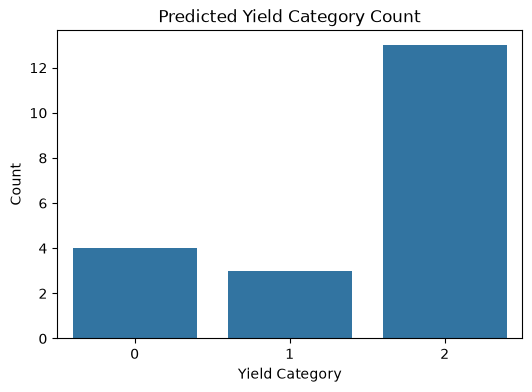

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X = df.drop('Yeild (Q/acre)', axis=1)
y = df['Yeild (Q/acre)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

min_yield = df['Yeild (Q/acre)'].min()
max_yield = df['Yeild (Q/acre)'].max()
bins = np.linspace(min_yield, max_yield, 4)

y_pred_category = pd.cut(y_pred, bins=bins, labels=[0, 1, 2], include_lowest=True)

pred_counts = y_pred_category.value_counts().sort_index()

plt.figure(figsize=(6, 4))
sns.barplot(x=pred_counts.index.astype(str), y=pred_counts.values)
plt.title('Predicted Yield Category Count')
plt.xlabel('Yield Category')
plt.ylabel('Count')
plt.show()


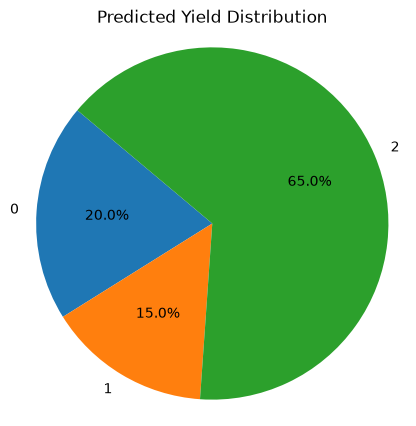

In [25]:
# Pie chart
plt.figure(figsize=(5, 5))

plt.pie(
    pred_counts.values,
    labels=pred_counts.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title('Predicted Yield Distribution')
plt.axis('equal')
plt.show()